# DATA

## EXTRACCION DE DATOS
Para el desarrollo de este proyecto se recurrió a dos tipos de fuentes. Por un lado, las pistas de audio utilizadas para construir el dataset fueron obtenidas de Free Music Archive (https://freemusicarchive.org), plataforma de distribución musical que ofrece canciones bajo licencias Creative Commons, permitiendo su uso libre en contextos académicos e investigativos sin restricciones de derechos de autor. Las canciones fueron seleccionadas y organizadas manualmente por género musical, garantizando un mínimo de 50 pistas por categoría.

## PROCESAMIENTO Y MODELAMIENTO DE LOS DATOS

### Librerias 
Librosa: es una librería especializada en análisis de audio y música que permite cargar archivos de sonido y extraer características acústicas. Es el núcleo del proceso de extracción de features en este proyecto.

NumPy: es la librería fundamental para computación numérica en Python. Proporciona estructuras de datos tipo array de alto rendimiento y operaciones matemáticas vectorizadas, siendo la base sobre la que trabajan la mayoría de librerías científicas incluyendo Librosa.

Pandas es la librería estándar para manipulación y análisis de datos tabulares en Python. Permite construir, limpiar y transformar dataframes, que es la estructura utilizada para almacenar y exportar el dataset final en formato CSV.

Os es un módulo nativo de Python que permite interactuar con el sistema operativo, específicamente con el sistema de archivos. En este proyecto se utiliza para recorrer las carpetas de géneros, listar los archivos de audio disponibles y construir las rutas de acceso a cada canción.

### Extracción de Features 
El código implementa un pipeline de extracción automática de características acústicas a partir de archivos de audio organizados por género musical. Para cada canción se carga la pista completa y se extraen tres segmentos de 30 segundos correspondientes al inicio, la mitad y el final de la pista. De cada segmento se calculan 27 features: siete características acústicas globales (tempo, spectral centroid, spectral bandwidth, rolloff, zero crossing rate, RMS energy y chroma STFT) y 20 coeficientes MFCC que representan el timbre de la señal. Cada segmento procesado queda registrado como una fila independiente en el dataset, junto con su etiqueta de género y el nombre del archivo de origen. El resultado final es un archivo CSV estructurado y listo para la etapa de modelado.

## CODIGO PARA SEGMENTOS DE 30s

In [ ]:
import librosa
import numpy as np
import pandas as pd
import os
import warnings
from tqdm import tqdm

warnings.filterwarnings('ignore')

def extraerfeatures(y, sr):
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    
    features = {
        'tempo':               librosa.beat.tempo(y=y, sr=sr)[0],
        'spectral_centroid':   librosa.feature.spectral_centroid(y=y, sr=sr).mean(),
        'spectral_bandwidth':  librosa.feature.spectral_bandwidth(y=y, sr=sr).mean(),
        'rolloff':             librosa.feature.spectral_rolloff(y=y, sr=sr).mean(),
        'zero_crossing_rate':  librosa.feature.zero_crossing_rate(y).mean(),
        'rms':                 librosa.feature.rms(y=y).mean(),
        'chroma_stft':         chroma.mean(),
        'onset_strength_mean': onset_env.mean(),
        'onset_strength_std':  onset_env.std(),
        'pitch_variance':      chroma.var(),
        'spectral_flux_std':   onset_env.std() 
    }
    
    for i, coef in enumerate(mfccs):
        features[f'mfcc{i+1}_mean'] = coef.mean()
        features[f'mfcc{i+1}_std']  = coef.std()
        
    return features

# --- CONFIGURACIÓN ---
filas = []
carpeta_raiz = 'data/raw/songs' 

# Contadores para el reporte
stats = {"procesados": 0, "error_lectura": 0, "muy_cortos": 0}

generos = [d for d in os.listdir(carpeta_raiz) if os.path.isdir(os.path.join(carpeta_raiz, d))]

for genero in generos:
    carpeta_genero = os.path.join(carpeta_raiz, genero)
    archivos_genero = [f for f in os.listdir(carpeta_genero) if f.endswith(('.mp3', '.wav'))]
    
    for archivo in tqdm(archivos_genero, desc=f"Procesando {genero}"):
        ruta = os.path.join(carpeta_genero, archivo)
        try:
            # Cargamos el audio
            y, sr = librosa.load(ruta, sr=None)
            duracion = librosa.get_duration(y=y, sr=sr)

            # LÓGICA DE SEGMENTACIÓN DINÁMICA: Rescata canciones cortas
            puntos_segmento = []
            
            if duracion >= 85:
                # Caso estándar: 3 segmentos
                puntos_segmento = [
                    (0, "inicio"), 
                    (int(duracion/2)-15, "mitad"), 
                    (int(duracion)-30, "final")
                ]
            elif duracion >= 60:
                # Rescate: 2 segmentos
                puntos_segmento = [(0, "inicio"), (int(duracion)-30, "final")]
            elif duracion >= 30:
                # Rescate mínimo: 1 segmento
                puntos_segmento = [(0, "unico")]
            else:
                stats["muy_cortos"] += 1
                continue

            for inicio_seg, nombre_seg in puntos_segmento:
                inicio_p = int(inicio_seg * sr)
                fin_p    = int((inicio_seg + 30) * sr)
                segmento = y[inicio_p:fin_p]

                # Margen de seguridad de 29s para evitar errores de redondeo
                if len(segmento) >= int(29 * sr): 
                    features = extraerfeatures(segmento, sr)
                    features['label'] = genero
                    features['song_id'] = archivo
                    features['segment_type'] = nombre_seg
                    filas.append(features)
            
            stats["procesados"] += 1

        except Exception:
            stats["error_lectura"] += 1
            continue

# CREACIÓN DEL DATAFRAME
df = pd.DataFrame(filas)

# --- REPORTE FINAL ---
print(f"\n--- RESUMEN DEL PROCESO ACTUALIZADO ---")
print(f"Canciones procesadas con éxito: {stats['procesados']}")
print(f"Canciones saltadas (menos de 30s): {stats['muy_cortos']}")
print(f"Canciones con error de archivo: {stats['error_lectura']}")
print(f"Total de segmentos en el DataFrame: {df.shape[0]}")
print(f"\nDistribución por género:\n{df['label'].value_counts()}")


'\nimport librosa\nimport numpy as np\nimport pandas as pd\nimport os\nimport warnings\nfrom tqdm import tqdm\n\nwarnings.filterwarnings(\'ignore\')\n\ndef extraerfeatures(y, sr):\n    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)\n    onset_env = librosa.onset.onset_strength(y=y, sr=sr)\n    chroma = librosa.feature.chroma_stft(y=y, sr=sr)\n\n    features = {\n        \'tempo\':               librosa.beat.tempo(y=y, sr=sr)[0],\n        \'spectral_centroid\':   librosa.feature.spectral_centroid(y=y, sr=sr).mean(),\n        \'spectral_bandwidth\':  librosa.feature.spectral_bandwidth(y=y, sr=sr).mean(),\n        \'rolloff\':             librosa.feature.spectral_rolloff(y=y, sr=sr).mean(),\n        \'zero_crossing_rate\':  librosa.feature.zero_crossing_rate(y).mean(),\n        \'rms\':                 librosa.feature.rms(y=y).mean(),\n        \'chroma_stft\':         chroma.mean(),\n        \'onset_strength_mean\': onset_env.mean(),\n        \'onset_strength_std\':  onset_env.std(),

In [ ]:
df.info()

## ETL CON VENTANAS DESLIZANTES (15s, solapamiento 1s)

Esta variación del ETL original procesa cada canción usando ventanas deslizantes
de 15 segundos con 1 segundo de solapamiento entre ventanas consecutivas
(paso de 14 segundos). A diferencia del ETL original que extraía 1 a 3
segmentos fijos por canción, este enfoque genera una secuencia densa de
segmentos que captura la evolución temporal de las características acústicas
a lo largo de toda la pista.

**Fuente de audio:** `/home/pxtroniwnl/Downloads/songs` (7 géneros, ~50 canciones cada uno)

**Cambios respecto al ETL original:**
- Segmentos de 15s en lugar de 30s
- Solapamiento de 1s entre ventanas consecutivas
- Todas las canciones de ≥15s se procesan (no solo las de ≥30s)
- Los segmentos se nombran como `seg_XXXX` en orden secuencial
- El archivo de salida es `data/dataset_15s_overlap.csv`

In [1]:
import librosa
import numpy as np
import pandas as pd
import os
import random
import warnings
from tqdm import tqdm

warnings.filterwarnings('ignore')


def extraerfeatures(y, sr):
    """
    Extrae características acústicas de una señal de audio.

    Parámetros
    ----------
    y : np.ndarray
        Señal de audio en el dominio del tiempo.
    sr : int
        Frecuencia de muestreo en Hz.

    Retorna
    -------
    dict
        Diccionario con 37 características: tempo, spectral centroid,
        spectral bandwidth, rolloff, zero crossing rate, RMS, chroma STFT,
        onset strength (media y std), pitch variance, spectral flux std,
        y 13 coeficientes MFCC (media y std cada uno).
    """
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)

    features = {
        'tempo': (
            librosa.beat.tempo(y=y, sr=sr)[0]
        ),
        'spectral_centroid': (
            librosa.feature.spectral_centroid(y=y, sr=sr).mean()
        ),
        'spectral_bandwidth': (
            librosa.feature.spectral_bandwidth(y=y, sr=sr).mean()
        ),
        'rolloff': librosa.feature.spectral_rolloff(y=y, sr=sr).mean(),
        'zero_crossing_rate': (
            librosa.feature.zero_crossing_rate(y).mean()
        ),
        'rms': librosa.feature.rms(y=y).mean(),
        'chroma_stft': chroma.mean(),
        'onset_strength_mean': onset_env.mean(),
        'onset_strength_std': onset_env.std(),
        'pitch_variance': chroma.var(),
        'spectral_flux_std': onset_env.std(),
    }

    for i, coef in enumerate(mfccs):
        features[f'mfcc{i + 1}_mean'] = coef.mean()
        features[f'mfcc{i + 1}_std'] = coef.std()

    return features


# --- CONFIGURACIÓN ---
CARPETA_RAIZ = '/home/pxtroniwnl/Downloads/songs'
DURACION_VENTANA = 15  # segundos por segmento
SOLAPAMIENTO = 1       # segundos de superposición entre ventanas
PASO = DURACION_VENTANA - SOLAPAMIENTO  # 14 segundos
MAX_SEGMENTOS_POR_CANCION = 15  # tope para balancear clases
ARCHIVO_SALIDA = 'data/dataset_15s_overlap.csv'

filas = []
stats = {'procesados': 0, 'error_lectura': 0, 'muy_cortos': 0}

generos = [
    d for d in os.listdir(CARPETA_RAIZ)
    if os.path.isdir(os.path.join(CARPETA_RAIZ, d))
]

print('Iniciando ETL con ventanas deslizantes de 15s y 1s de '
      'solapamiento...')
print(f'Géneros encontrados: {generos}\n')

for genero in generos:
    carpeta_genero = os.path.join(CARPETA_RAIZ, genero)
    archivos_genero = [
        f for f in os.listdir(carpeta_genero)
        if f.endswith(('.mp3', '.wav'))
    ]

    for archivo in tqdm(archivos_genero, desc=f'Procesando {genero}'):
        ruta = os.path.join(carpeta_genero, archivo)

        try:
            y, sr = librosa.load(ruta, sr=None)
            duracion = librosa.get_duration(y=y, sr=sr)

            # --- VENTANA DESLIZANTE ---
            # Se generan segmentos de DURACION_VENTANA segundos
            # avanzando PASO segundos cada vez, lo que produce un
            # solapamiento de SOLAPAMIENTO segundos entre ventanas
            if duracion >= DURACION_VENTANA:
                num_segmento = 0
                inicio = 0.0
                segmentos_temp = []  # lista temporal para
                # aplicar el tope por canción

                while inicio + DURACION_VENTANA <= duracion:
                    inicio_p = int(inicio * sr)
                    fin_p = int((inicio + DURACION_VENTANA) * sr)
                    segmento = y[inicio_p:fin_p]

                    # Margen de seguridad: al menos 14s
                    # para evitar errores de redondeo
                    if len(segmento) >= int(14 * sr):
                        features = extraerfeatures(segmento, sr)
                        features['label'] = genero
                        features['song_id'] = archivo
                        features['segment_type'] = (
                            f'seg_{num_segmento:04d}'
                        )
                        segmentos_temp.append(features)

                    inicio += PASO
                    num_segmento += 1

                # Balanceo: si la canción genera más segmentos
                # que el máximo permitido, se muestrean
                # aleatoriamente para evitar que los géneros
                # con canciones más largas dominen el dataset
                if len(segmentos_temp) > MAX_SEGMENTOS_POR_CANCION:
                    segmentos_temp = random.sample(
                        segmentos_temp, MAX_SEGMENTOS_POR_CANCION
                    )

                filas.extend(segmentos_temp)
                stats['procesados'] += 1

            else:
                stats['muy_cortos'] += 1

        except Exception:
            stats['error_lectura'] += 1
            continue

# --- CREACIÓN DEL DATAFRAME ---
df = pd.DataFrame(filas)

# --- EXPORTACIÓN A CSV ---
df.to_csv(ARCHIVO_SALIDA, index=False)
print(f'\nDataset exportado a: {ARCHIVO_SALIDA}')

# --- REPORTE FINAL ---
print(f'\n{"=" * 55}')
print('  REPORTE FINAL — ETL VENTANAS DESLIZANTES '
      '(15s, 1s solapamiento)')
print(f'{"=" * 55}')
print(f'  Ventana: {DURACION_VENTANA}s | Solapamiento: '
      f'{SOLAPAMIENTO}s | Tope por canción: '
      f'{MAX_SEGMENTOS_POR_CANCION}')
print(f'{"-" * 55}')
print(f'  Canciones procesadas con éxito:   '
      f'{stats["procesados"]}')
print(f'  Canciones saltadas (<{DURACION_VENTANA}s): '
      f'{stats["muy_cortos"]}')
print(f'  Canciones con error de lectura:   '
      f'{stats["error_lectura"]}')
print(f'  Total de segmentos generados:     {df.shape[0]}')
print(f'  Número de características:        {df.shape[1] - 3}')
print(f'  Géneros incluidos:                '
      f'{df["label"].nunique()}')
print(f'\n  Distribución por género:')
for genero, count in df['label'].value_counts().items():
    print(f'    {genero}: {count} segmentos')
print(f'{"=" * 55}')


Iniciando ETL con ventanas deslizantes de 15s y 1s de solapamiento...
Géneros encontrados: ['Vallenato', 'pop', 'Hip-Hop', 'jazz', 'clasicc', 'Electronica', 'Rock']



Procesando pop:   2%|▏         | 1/50 [00:02<02:07,  2.60s/it]Note: Illegal Audio-MPEG-Header 0x30304205 at offset 68579.
Note: Trying to resync...
Note: Skipped 105 bytes in input.
[src/libmpg123/parse.c:skip_junk():1260] error: Giving up searching valid MPEG header after 65536 bytes of junk.
Procesando pop:  10%|█         | 5/50 [00:14<02:26,  3.25s/it]Note: Illegal Audio-MPEG-Header 0xffeb0019 at offset 62228.
Note: Trying to resync...
Note: Skipped 120 bytes in input.
[src/libmpg123/parse.c:skip_junk():1260] error: Giving up searching valid MPEG header after 65536 bytes of junk.
Procesando pop:  12%|█▏        | 6/50 [00:18<02:36,  3.55s/it][src/libmpg123/layer1.c:check_balloc():30] error: Illegal bit allocation value.
[src/libmpg123/layer1.c:INT123_do_layer1():228] error: Aborting layer I decoding after step one.
[src/libmpg123/layer1.c:check_balloc():30] error: Illegal bit allocation value.
[src/libmpg123/layer1.c:INT123_do_layer1():228] error: Aborting layer I decoding after step


Dataset exportado a: data/dataset_15s_overlap.csv

  REPORTE FINAL — ETL VENTANAS DESLIZANTES (15s, 1s solapamiento)
  Ventana: 15s | Solapamiento: 1s | Tope por canción: 15
-------------------------------------------------------
  Canciones procesadas con éxito:   342
  Canciones saltadas (<15s): 7
  Canciones con error de lectura:   1
  Total de segmentos generados:     4785
  Número de características:        37
  Géneros incluidos:                7

  Distribución por género:
    clasicc: 746 segmentos
    Vallenato: 729 segmentos
    jazz: 706 segmentos
    Electronica: 705 segmentos
    Rock: 679 segmentos
    pop: 670 segmentos
    Hip-Hop: 550 segmentos


In [2]:
df

,tempo,spectral_centroid,spectral_bandwidth,rolloff,zero_crossing_rate,rms,chroma_stft,onset_strength_mean,onset_strength_std,pitch_variance,...,mfcc10_std,mfcc11_mean,mfcc11_std,mfcc12_mean,mfcc12_std,mfcc13_mean,mfcc13_std,label,song_id,segment_type
0,140.625000,3173.211903,3638.048714,7005.896855,0.056569,0.251313,0.348571,1.287109,1.157778,0.102008,...,9.689957,-3.558281,10.337765,2.964497,10.813516,7.533074,9.758651,Vallenato,Jose Carrascal - Como Duele El Frio.mp3,seg_0002
1,140.625000,3025.349981,3341.683589,6430.570362,0.059305,0.162415,0.378989,1.415164,1.793468,0.095830,...,12.345153,-5.619614,11.635130,-6.509331,10.464228,0.403008,11.000497,Vallenato,Jose Carrascal - Como Duele El Frio.mp3,seg_0000
2,140.625000,3399.487612,3815.175304,7523.970549,0.061829,0.239752,0.379100,1.317770,1.200475,0.098138,...,9.847819,-6.292233,9.763202,-2.240828,9.716574,2.045806,8.724630,Vallenato,Jose Carrascal - Como Duele El Frio.mp3,seg_0016
3,140.625000,3259.599243,3746.383501,7308.368870,0.058821,0.271174,0.347633,1.275700,1.156200,0.094394,...,10.244502,-7.048702,9.298923,2.831871,11.342535,5.951617,9.704350,Vallenato,Jose Carrascal - Como Duele El Frio.mp3,seg_0003
4,140.625000,3708.612862,4049.893238,8345.232543,0.068874,0.280125,0.383995,1.351518,1.233323,0.098357,...,9.662303,-6.709998,10.317873,4.413290,11.986065,5.639030,9.831874,Vallenato,Jose Carrascal - Como Duele El Frio.mp3,seg_0004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4780,84.720799,1988.786314,2700.406864,3818.610243,0.038757,0.194272,0.447379,1.130572,0.996664,0.092014,...,9.896713,-2.938755,8.663389,2.393089,10.332759,5.354336,8.042583,Rock,Arctic Monkeys - Do I Wanna Know_ Official Vid...,seg_0003
4781,112.347147,1994.233062,2615.444002,3860.559989,0.040373,0.177605,0.459498,1.110262,0.895496,0.087937,...,9.105460,-3.503818,8.192700,2.433516,8.213352,6.807912,7.465317,Rock,Arctic Monkeys - Do I Wanna Know_ Official Vid...,seg_0004
4782,84.720799,1170.530846,1630.140983,2310.086031,0.023397,0.165290,0.561854,0.962761,1.275862,0.073782,...,7.384136,-2.948964,6.693588,1.111050,6.547799,5.792864,6.182925,Rock,Arctic Monkeys - Do I Wanna Know_ Official Vid...,seg_0001
4783,123.046875,2181.615566,2748.152580,4414.939970,0.047545,0.191194,0.453153,1.044097,0.733873,0.088058,...,8.920901,-2.523552,8.225388,3.612963,7.267481,6.133001,7.337834,Rock,Arctic Monkeys - Do I Wanna Know_ Official Vid...,seg_0005


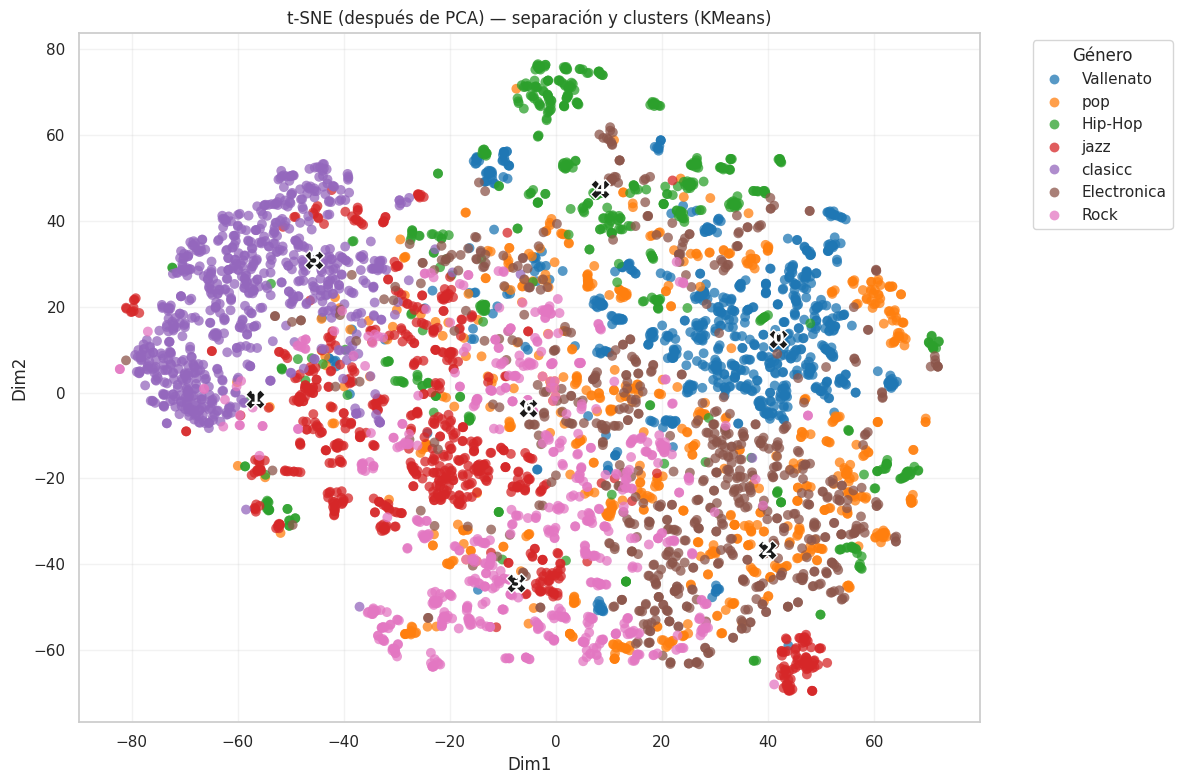

PCA explicado (primeros 5 componentes): [0.27079517 0.21302333 0.11141682 0.05099073 0.03801952]
Número de clusters (KMeans): 7


In [5]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style='whitegrid')

# Preparar los datos: excluir columnas no numéricas y NaNs
X = df.drop(['label', 'song_id', 'segment_type'], axis=1)
X = X.select_dtypes(include=[np.number]).fillna(0)
labels = df['label'].astype(str).values

# Escalado
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# PCA previo (reduce ruido y acelera t-SNE)
n_pca = min(50, Xs.shape[1])
pca = PCA(n_components=n_pca, random_state=42)
X_pca = pca.fit_transform(Xs)

# t-SNE para mejor separación visual (inicializado con PCA)
# Evitar argumentos incompatibles entre versiones de scikit-learn
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)
X_emb = tsne.fit_transform(X_pca)

plot_df = pd.DataFrame(X_emb, columns=['Dim1', 'Dim2'])
plot_df['label'] = labels

# KMeans para mostrar clusters (cantidad = número de géneros)
n_clusters = df['label'].nunique()
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit(X_emb)
plot_df['cluster'] = kmeans.labels_
centers = kmeans.cluster_centers_

plt.figure(figsize=(12, 8))
palette = sns.color_palette('tab10', n_clusters)
ax = sns.scatterplot(data=plot_df, x='Dim1', y='Dim2', hue='label', palette='tab10', alpha=0.75, s=50, linewidth=0)

# Dibujar centros de cluster
for i, (cx, cy) in enumerate(centers):
    plt.scatter(cx, cy, marker='X', s=200, c='k', edgecolor='white')
    plt.text(cx, cy, str(i), color='white', ha='center', va='center', weight='bold')

plt.title('t-SNE (después de PCA) — separación y clusters (KMeans)')
plt.xlabel('Dim1')
plt.ylabel('Dim2')
plt.legend(title='Género', bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print(f'PCA explicado (primeros 5 componentes): {pca.explained_variance_ratio_[:5]}')
print(f'Número de clusters (KMeans): {n_clusters}')